In [4]:
import os
os.chdir('/home/wiikai/factor')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import factorlab as lab
import quool
barra_returns = quool.DatetimeTable('/home/data/barra-returns-rq')

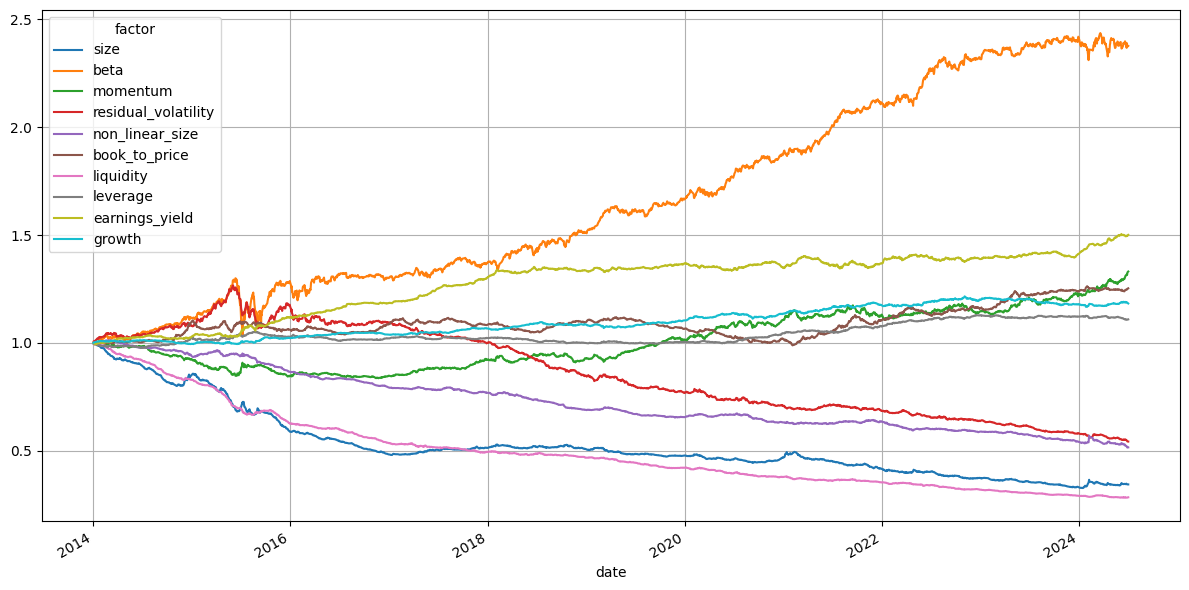

In [19]:
df = (1 + barra_returns.read(start='20140101', stop='20240701')).cumprod()
index = (1 + lab.index_quotes_day.read('close',code='000985.XSHG',start='20140101',stop='20240701').pct_change(fill_method=None)).cumprod()

df[['size', 'beta', 'momentum',
       'residual_volatility', 'non_linear_size', 'book_to_price',
       'liquidity', 'leverage', 'earnings_yield', 'growth']].plot(figsize=(12, 6), grid=True)  
plt.tight_layout() 

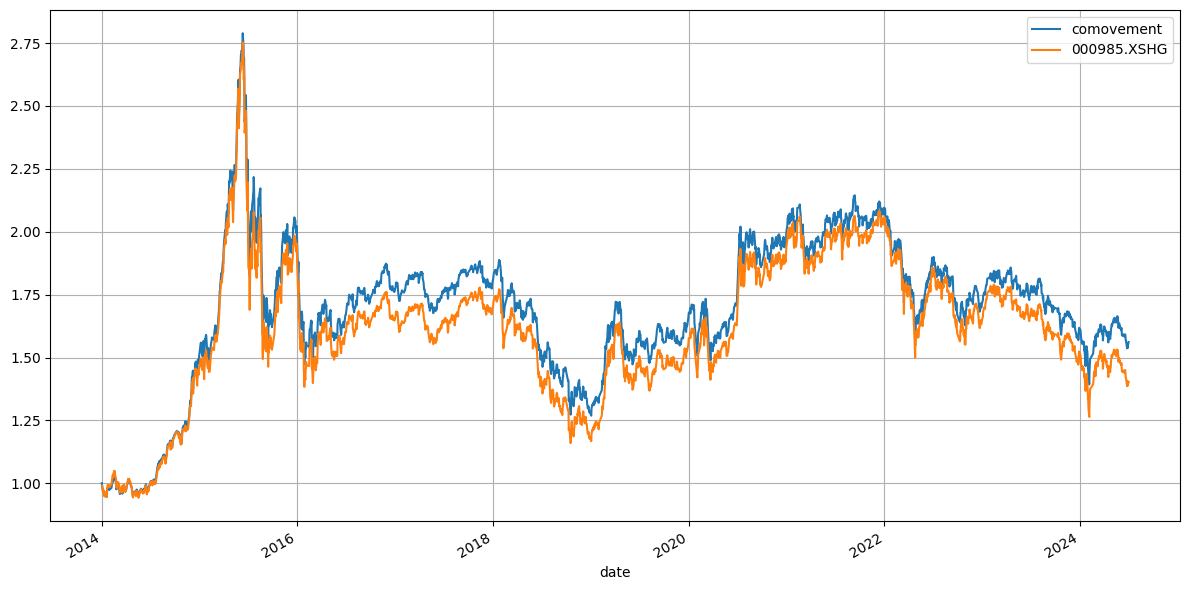

In [20]:
combined = pd.concat([df['comovement'], index['000985.XSHG']], axis=1).plot(figsize=(12, 6), grid=True)
plt.tight_layout()

In [21]:
df[['交通运输', '传媒', '农林牧渔', '医药', '商贸零售', '国防军工', '基础化工', '家电',
       '建材', '建筑', '房地产', '有色金属', '机械', '汽车', '消费者服务', '煤炭', '电力及公用事业',
       '电力设备及新能源', '电子', '石油石化', '纺织服装', '综合', '计算机', '轻工制造', '通信', '钢铁', '银行',
       '非银行金融', '食品饮料']].iloc[-1,:]

factor
交通运输        0.629344
传媒          1.603281
农林牧渔        1.737561
医药          1.649027
商贸零售        0.455140
国防军工        3.944340
基础化工        0.905909
家电          1.036582
建材          0.873844
建筑          0.634000
房地产         0.463832
有色金属        3.208062
机械          0.906664
汽车          1.047107
消费者服务       1.167159
煤炭          0.929358
电力及公用事业     0.468610
电力设备及新能源    1.611212
电子          2.277797
石油石化        0.551916
纺织服装        0.507778
综合          0.725317
计算机         2.831582
轻工制造        0.697553
通信          2.455980
钢铁          0.864601
银行          0.353757
非银行金融       0.660039
食品饮料        1.759478
Name: 2024-07-01 00:00:00, dtype: float64

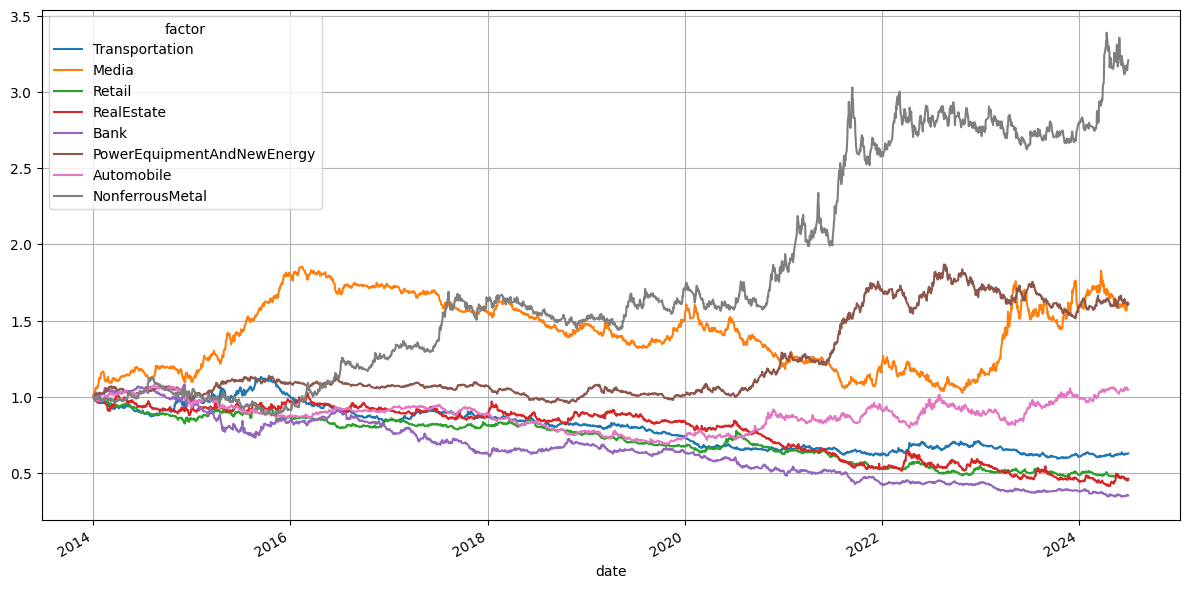

In [8]:
column_mapping = {
    '交通运输': 'Transportation',
    '传媒': 'Media',
    '农林牧渔': 'Agriculture',
    '医药': 'Medicine',
    '商贸零售': 'Retail',
    '国防军工': 'Defense',
    '基础化工': 'BasicChemical',
    '家电': 'HouseholdAppliance',
    '建材': 'BuildingMaterials',
    '建筑': 'Construction',
    '房地产': 'RealEstate',
    '有色金属': 'NonferrousMetal',
    '机械': 'Machinery',
    '汽车': 'Automobile',
    '消费者服务': 'ConsumerServices',
    '煤炭': 'Coal',
    '电力及公用事业': 'PowerAndUtilities',
    '电力设备及新能源': 'PowerEquipmentAndNewEnergy',
    '电子': 'Electronics',
    '石油石化': 'PetroleumAndChemical',
    '纺织服装': 'TextileAndApparel',
    '综合': 'Comprehensive',
    '计算机': 'Computer',
    '轻工制造': 'LightManufacturing',
    '通信': 'Communication',
    '钢铁': 'Steel',
    '银行': 'Bank',
    '非银行金融': 'NonBankFinancial',
    '食品饮料': 'FoodAndBeverage'
}
df = df.rename(columns=column_mapping)
df[['Transportation', 'Media', 'Retail', 'RealEstate', 'Bank', 'PowerEquipmentAndNewEnergy', 'Automobile', 'NonferrousMetal']].plot(figsize=(12, 6), grid=True)
plt.tight_layout()